# TSC of Abnormal Processes in CNC Machines

## Imports

In [1]:
# Utilities
from main import *
from data_loader_utils import *

import os
import itertools
from pathlib import Path
import pickle

In [2]:
# Models
# FreshPrince
from sklearn.pipeline import Pipeline
from sktime.transformations.panel.tsfresh import TSFreshFeatureExtractor
from sktime.classification.sklearn import RotationForest
# DrCIF
from sktime.classification.interval_based import DrCIF
# STC
from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
# TDE
from sktime.classification.dictionary_based import TemporalDictionaryEnsemble
# MiniROCKET
from sktime.pipeline import make_pipeline
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import LogisticRegression
# ITC
from sktime.classification.deep_learning import InceptionTimeClassifier

## Data Loading

In [3]:
machines = ["M01", "M02","M03"]
process_names = ["OP00","OP01","OP02","OP03","OP04","OP05","OP06","OP07","OP08","OP09","OP10","OP11","OP12","OP13","OP14"]
labels = ["good","bad"]
path_to_dataset = Path("./data/").absolute()

In [4]:
X_data = []
y_data = []

for process_name, machine, label in itertools.product(process_names, machines, labels):
    data_path = os.path.join(path_to_dataset, machine, process_name, label)
    data_list, data_label = load_tool_research_data(data_path, label=label, add_additional_label = True, verbose = False)
    X_data.extend(data_list)
    y_data.extend(data_label)

df = get_df(X_data, y_data)

In [5]:
trf = MiniRocketMultivariate(n_jobs = 1) 
clf = LogisticRegression(n_jobs = 1)

mr_baseline = make_pipeline(trf, clf)

Testing machine-wise split
Testing time-wise split
Testing operation-wise split


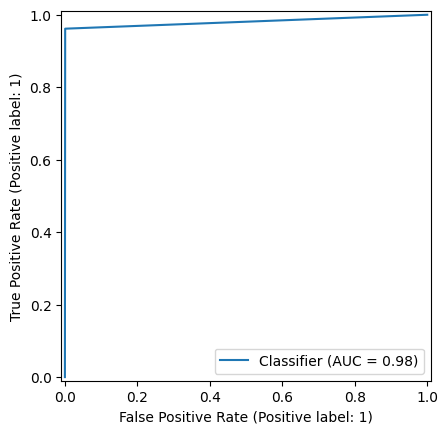

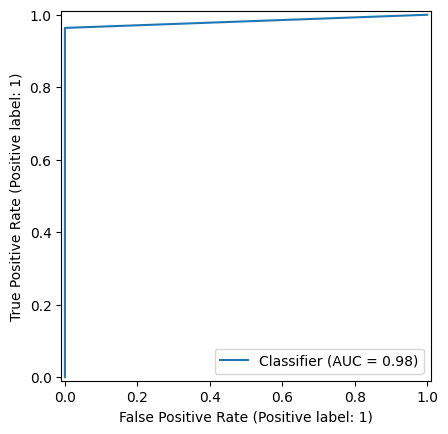

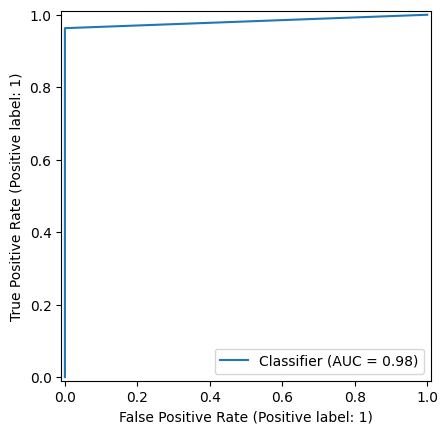

In [6]:
results, objects = get_test_results(mr_baseline, df)

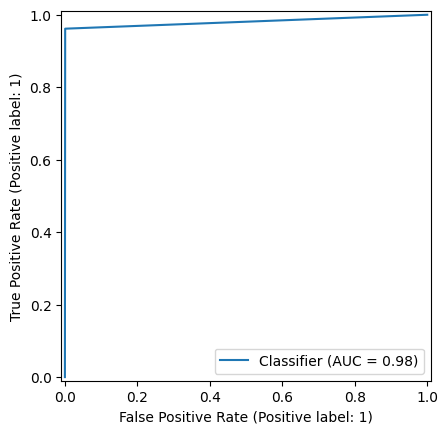

In [9]:
results["model_display"][0].plot()